## Khai báo thư viện và cấu hình Reproducibility

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Thiết bị đang sử dụng: {device}")

Thiết bị đang sử dụng: cpu


## Tải dữ liệu, tiền xử lý và chia tập Train/Val/Test

In [3]:
df = pd.read_csv("vietnam_housing_dataset.csv")

print("Danh sách các cột hiện có trong tập dữ liệu:")
print(df.columns.tolist())
print("\nXem thử 3 dòng đầu tiên:")
display(df.head(3))

# Tự động xác định cột giá nhà (cột chứa từ khóa 'price' hoặc cột cuối cùng)
price_cols = [c for c in df.columns if 'price' in c.lower()]
TARGET_COL = price_cols[0] if len(price_cols) > 0 else df.columns[-1]
print(f"\nCột mục tiêu được chọn làm biến giá nhà: '{TARGET_COL}'")

# Xử lý các cột dạng chữ/phân loại sang số học bằng category codes
df_processed = df.copy()
for col in df_processed.columns:
    if col != TARGET_COL:
        if not pd.api.types.is_numeric_dtype(df_processed[col]):
            df_processed[col] = df_processed[col].astype('category').cat.codes

# Ép kiểu dữ liệu mục tiêu về số thực và loại bỏ các dòng bị khuyết thiếu (NaN)
df_processed[TARGET_COL] = pd.to_numeric(df_processed[TARGET_COL], errors='coerce')
df_processed = df_processed.dropna()

# Tách biến đặc trưng X và biến mục tiêu liên tục y
X = df_processed.drop(columns=[TARGET_COL]).values.astype(np.float32)
y = df_processed[TARGET_COL].values.astype(np.float32).reshape(-1, 1)

# Phân chia dữ liệu theo tỷ lệ 70% Train - 15% Val - 15% Test
N = len(X)
indices = np.random.permutation(N)

train_end = int(0.70 * N)
val_end = int(0.85 * N)

train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]
test_idx = indices[val_end:]

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

# Chuẩn hóa Z-score: mean và std CHỈ tính toán trên tập Train (tránh rò rỉ thông tin)
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0) + 1e-8

y_mean = y_train.mean()
y_std = y_train.std() + 1e-8

X_train = (X_train - X_mean) / X_std
X_val = (X_val - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

y_train_norm = (y_train - y_mean) / y_std
y_val_norm = (y_val - y_mean) / y_std
y_test_norm = (y_test - y_mean) / y_std

INPUT_DIM = X_train.shape[1]
print(f"\nSố chiều đặc trưng đầu vào (INPUT_DIM): {INPUT_DIM}")
print(f"Kích thước tập Train     : {X_train.shape[0]} mẫu")
print(f"Kích thước tập Validation: {X_val.shape[0]} mẫu")
print(f"Kích thước tập Test       : {X_test.shape[0]} mẫu")

Danh sách các cột hiện có trong tập dữ liệu:
['Address', 'Area', 'Frontage', 'Access Road', 'House direction', 'Balcony direction', 'Floors', 'Bedrooms', 'Bathrooms', 'Legal status', 'Furniture state', 'Price']

Xem thử 3 dòng đầu tiên:


,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.6
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.5
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.9



Cột mục tiêu được chọn làm biến giá nhà: 'Price'

Số chiều đặc trưng đầu vào (INPUT_DIM): 11
Kích thước tập Train     : 8399 mẫu
Kích thước tập Validation: 1800 mẫu
Kích thước tập Test       : 1800 mẫu


## Đóng gói PyTorch Dataset và DataLoader

In [4]:
train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train_norm))
val_dataset = TensorDataset(torch.tensor(X_val), torch.tensor(y_val_norm))
test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test_norm))

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Số lượng mini-batches trên mỗi Epoch (Train): {len(train_loader)}")

Số lượng mini-batches trên mỗi Epoch (Train): 263


## Định nghĩa các kiến trúc mạng nơ-ron (Baseline MLP & Deeper MLP)

In [5]:
# Kiến trúc 1: Baseline MLP (d -> 64 -> 1)
class BaselineHousingMLP(nn.Module):
    def __init__(self, input_dim=INPUT_DIM):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.relu = nn.ReLU()
        self.fc_out = nn.Linear(64, 1)  # Đầu ra là 1 giá trị liên tục
        
    def forward(self, x):
        h = self.relu(self.fc1(x))
        return self.fc_out(h)

    def get_representation(self, x):
        return self.relu(self.fc1(x))

# Kiến trúc 2: Deeper MLP (d -> 64 -> 32 -> 1)
class DeeperHousingMLP(nn.Module):
    def __init__(self, input_dim=INPUT_DIM):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(64, 32)
        self.relu2 = nn.ReLU()
        self.fc_out = nn.Linear(32, 1)  # Đầu ra là 1 giá trị liên tục
        
    def forward(self, x):
        h1 = self.relu1(self.fc1(x))
        h2 = self.relu2(self.fc2(h1))
        return self.fc_out(h2)

    def get_representation(self, x):
        h1 = self.relu1(self.fc1(x))
        return self.relu2(self.fc2(h1))

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Tổng số tham số Baseline Housing MLP: {count_parameters(BaselineHousingMLP())}")
print(f"Tổng số tham số Deeper Housing MLP  : {count_parameters(DeeperHousingMLP())}")

Tổng số tham số Baseline Housing MLP: 833
Tổng số tham số Deeper Housing MLP  : 2881


## Xây dựng hàm huấn luyện (Training Loop) và đánh giá (Evaluation)

In [6]:
def train_epoch_reg(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss, total_samples = 0.0, 0
    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * X_batch.size(0)
        total_samples += X_batch.size(0)
    return running_loss / total_samples

def evaluate_reg(model, dataloader, criterion, device):
    model.eval()
    running_loss, total_samples = 0.0, 0
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            running_loss += loss.item() * X_batch.size(0)
            total_samples += X_batch.size(0)
    return running_loss / total_samples

def train_model_reg(model, train_loader, val_loader, criterion, optimizer, epochs=50, device=device):
    history = {'train_loss': [], 'val_loss': []}
    for epoch in range(epochs):
        t_loss = train_epoch_reg(model, train_loader, criterion, optimizer, device)
        v_loss = evaluate_reg(model, val_loader, criterion, device)
        
        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1:2d}/{epochs}] | Train MSE: {t_loss:.4f} | Val MSE: {v_loss:.4f}")
    return history

## Thực nghiệm

In [7]:
criterion = nn.MSELoss()
EPOCHS = 50

# --- Thực nghiệm 1: Baseline MLP (Adam, lr=0.001) ---
print("\n>>> Thực nghiệm 1: Baseline MLP (Adam) <<<")
set_seed(42)
model_exp1 = BaselineHousingMLP().to(device)
optimizer_exp1 = optim.Adam(model_exp1.parameters(), lr=0.001)
history_exp1 = train_model_reg(model_exp1, train_loader, val_loader, criterion, optimizer_exp1, epochs=EPOCHS)
print(f"Exp 1 Final Val MSE: {history_exp1['val_loss'][-1]:.4f}")

# --- Thực nghiệm 2: Deeper MLP (Adam, lr=0.001) ---
print("\n>>> Thực nghiệm 2: Deeper MLP (Adam) <<<")
set_seed(42)
model_exp2 = DeeperHousingMLP().to(device)
optimizer_exp2 = optim.Adam(model_exp2.parameters(), lr=0.001)
history_exp2 = train_model_reg(model_exp2, train_loader, val_loader, criterion, optimizer_exp2, epochs=EPOCHS)
print(f"Exp 2 Final Val MSE: {history_exp2['val_loss'][-1]:.4f}")

# --- Thực nghiệm 3: Deeper MLP (SGD Momentum, lr=0.01) ---
print("\n>>> Thực nghiệm 3: Deeper MLP (SGD Momentum) <<<")
set_seed(42)
model_exp3 = DeeperHousingMLP().to(device)
optimizer_exp3 = optim.SGD(model_exp3.parameters(), lr=0.01, momentum=0.9)
history_exp3 = train_model_reg(model_exp3, train_loader, val_loader, criterion, optimizer_exp3, epochs=EPOCHS)
print(f"Exp 3 (SGD) Final Val MSE: {history_exp3['val_loss'][-1]:.4f}")


>>> Thực nghiệm 1: Baseline MLP (Adam) <<<
Epoch [ 1/50] | Train MSE: 0.7656 | Val MSE: 0.6883
Epoch [10/50] | Train MSE: 0.6163 | Val MSE: 0.6398
Epoch [20/50] | Train MSE: 0.6006 | Val MSE: 0.6358
Epoch [30/50] | Train MSE: 0.5908 | Val MSE: 0.6417
Epoch [40/50] | Train MSE: 0.5824 | Val MSE: 0.6374
Epoch [50/50] | Train MSE: 0.5758 | Val MSE: 0.6453
Exp 1 Final Val MSE: 0.6453

>>> Thực nghiệm 2: Deeper MLP (Adam) <<<
Epoch [ 1/50] | Train MSE: 0.7355 | Val MSE: 0.6734
Epoch [10/50] | Train MSE: 0.5965 | Val MSE: 0.6448
Epoch [20/50] | Train MSE: 0.5638 | Val MSE: 0.6401
Epoch [30/50] | Train MSE: 0.5471 | Val MSE: 0.6290
Epoch [40/50] | Train MSE: 0.5328 | Val MSE: 0.6375
Epoch [50/50] | Train MSE: 0.5188 | Val MSE: 0.6342
Exp 2 Final Val MSE: 0.6342

>>> Thực nghiệm 3: Deeper MLP (SGD Momentum) <<<
Epoch [ 1/50] | Train MSE: 0.7210 | Val MSE: 0.6725
Epoch [10/50] | Train MSE: 0.6007 | Val MSE: 0.6500
Epoch [20/50] | Train MSE: 0.5766 | Val MSE: 0.6351
Epoch [30/50] | Train MSE: 0

## Vẽ biểu đồ đối sánh đường cong huấn luyện (Loss Curves)

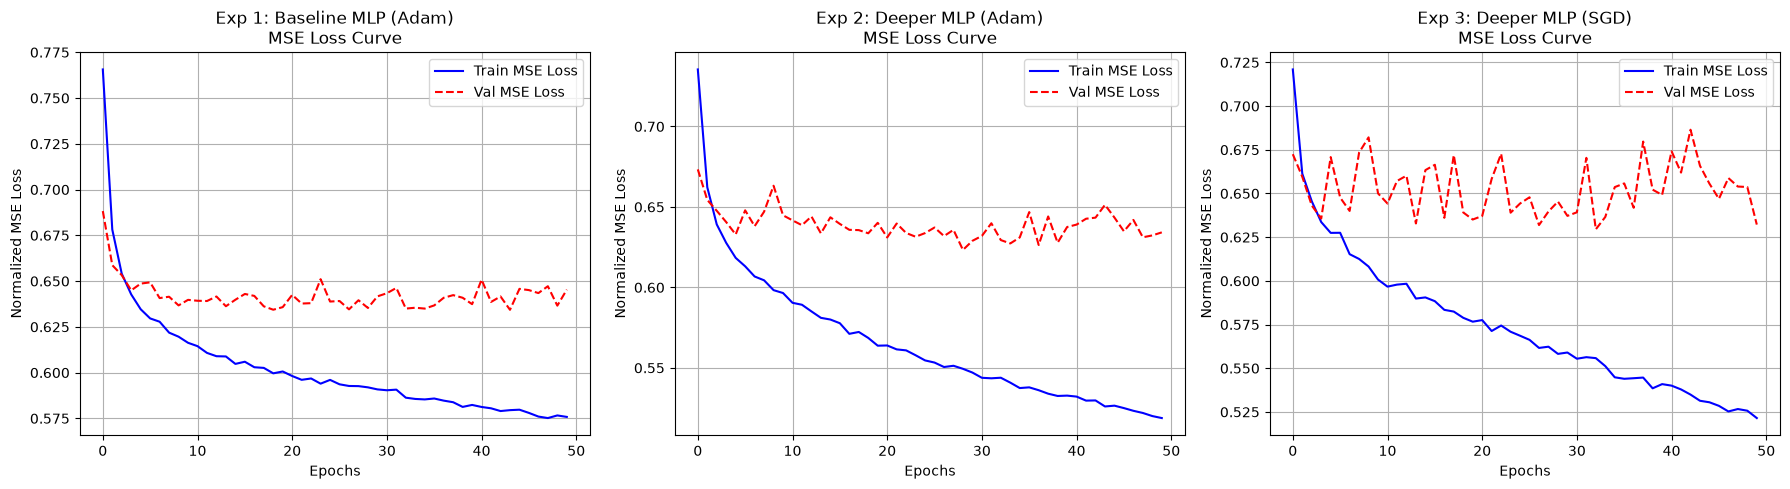

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

experiments = [
    ("Exp 1: Baseline MLP (Adam)", history_exp1),
    ("Exp 2: Deeper MLP (Adam)", history_exp2),
    ("Exp 3: Deeper MLP (SGD)", history_exp3)
]

for idx, (title, hist) in enumerate(experiments):
    axes[idx].plot(hist['train_loss'], label='Train MSE Loss', color='blue')
    axes[idx].plot(hist['val_loss'], label='Val MSE Loss', color='red', linestyle='--')
    axes[idx].set_title(f"{title}\nMSE Loss Curve")
    axes[idx].set_xlabel("Epochs")
    axes[idx].set_ylabel("Normalized MSE Loss")
    axes[idx].legend()
    axes[idx].grid(True)

plt.tight_layout()
plt.show()

## Đánh giá chi tiết trên tập Test và hiển thị Confusion Matrix

=== BẢNG TỔNG HỢP HIỆU NĂNG HỒI QUY TRÊN TẬP TEST ===
              Model  RMSE (Đơn vị gốc)  MAE (Đơn vị gốc)  R2-Score
Baseline MLP (Adam)             1.6969            1.3656    0.3936
  Deeper MLP (Adam)             1.7119            1.3773    0.3829
   Deeper MLP (SGD)             1.7301            1.3947    0.3697


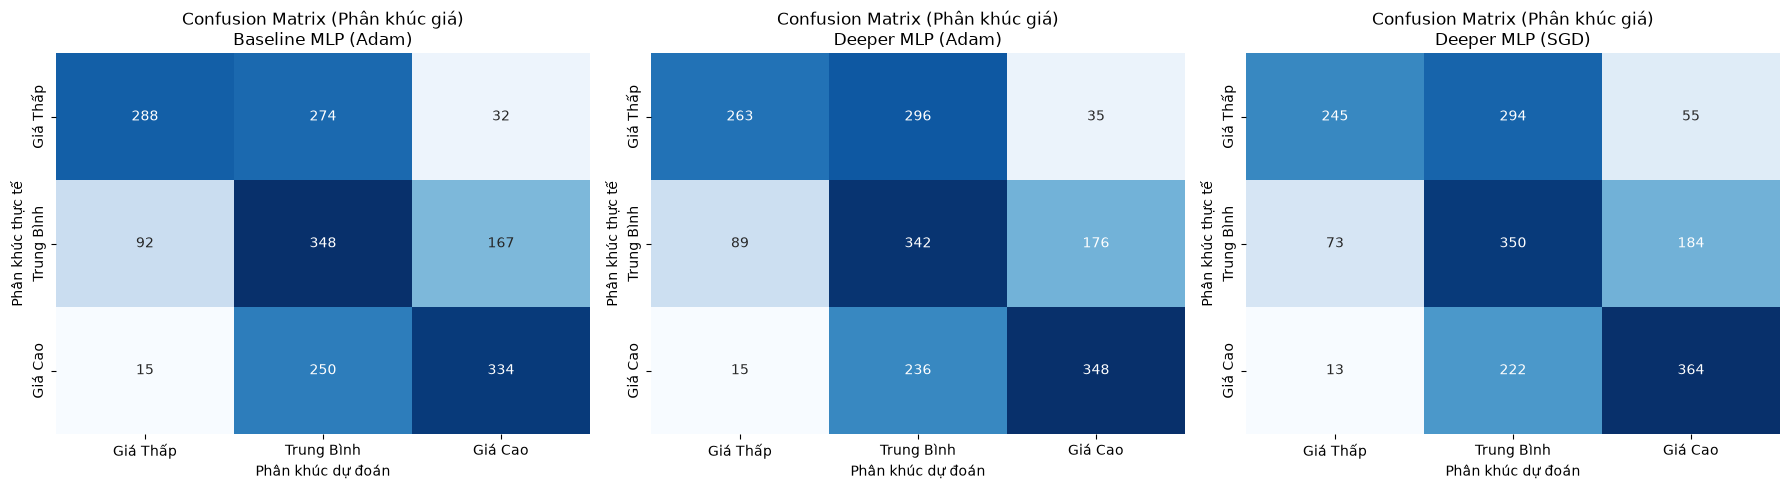

In [9]:
def compute_regression_metrics(model, X_arr, y_true_orig, y_m, y_s, device):
    model.eval()
    with torch.no_grad():
        preds_norm = model(torch.tensor(X_arr).to(device)).cpu().numpy()
    
    # Khôi phục về đơn vị giá gốc ban đầu của dữ liệu
    preds_orig = preds_norm * y_s + y_m
    
    rmse = np.sqrt(mean_squared_error(y_true_orig, preds_orig))
    mae = mean_absolute_error(y_true_orig, preds_orig)
    r2 = r2_score(y_true_orig, preds_orig)
    return rmse, mae, r2, preds_orig

models = {
    "Baseline MLP (Adam)": model_exp1,
    "Deeper MLP (Adam)": model_exp2,
    "Deeper MLP (SGD)": model_exp3
}

results = []
preds_dict = {}
for name, m in models.items():
    rmse, mae, r2, preds_orig = compute_regression_metrics(m, X_test, y_test, y_mean, y_std, device)
    preds_dict[name] = preds_orig
    results.append({
        "Model": name,
        "RMSE (Đơn vị gốc)": round(rmse, 4),
        "MAE (Đơn vị gốc)": round(mae, 4),
        "R2-Score": round(r2, 4)
    })

print("=== BẢNG TỔNG HỢP HIỆU NĂNG HỒI QUY TRÊN TẬP TEST ===")
print(pd.DataFrame(results).to_string(index=False))

# Để có Confusion Matrix trong bài toán hồi quy:
# Chia giá nhà thực tế thành 3 phân khúc dựa trên phân vị 33% và 66% (Thấp, Trung bình, Cao)
q33 = np.quantile(y_test, 0.33)
q66 = np.quantile(y_test, 0.66)

def bin_prices(price_array):
    bins = np.zeros(len(price_array), dtype=int)
    bins[(price_array >= q33) & (price_array <= q66)] = 1
    bins[price_array > q66] = 2
    return bins

y_true_binned = bin_prices(y_test.flatten())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_labels = ['Giá Thấp', 'Trung Bình', 'Giá Cao']

for idx, (name, _) in enumerate(models.items()):
    y_pred_binned = bin_prices(preds_dict[name].flatten())
    cm = confusion_matrix(y_true_binned, y_pred_binned)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=class_labels, yticklabels=class_labels, cbar=False)
    axes[idx].set_title(f"Confusion Matrix (Phân khúc giá)\n{name}")
    axes[idx].set_xlabel("Phân khúc dự đoán")
    axes[idx].set_ylabel("Phân khúc thực tế")

plt.tight_layout()
plt.show()

## Khám phá tầng biểu diễn ẩn (Learned Representation)

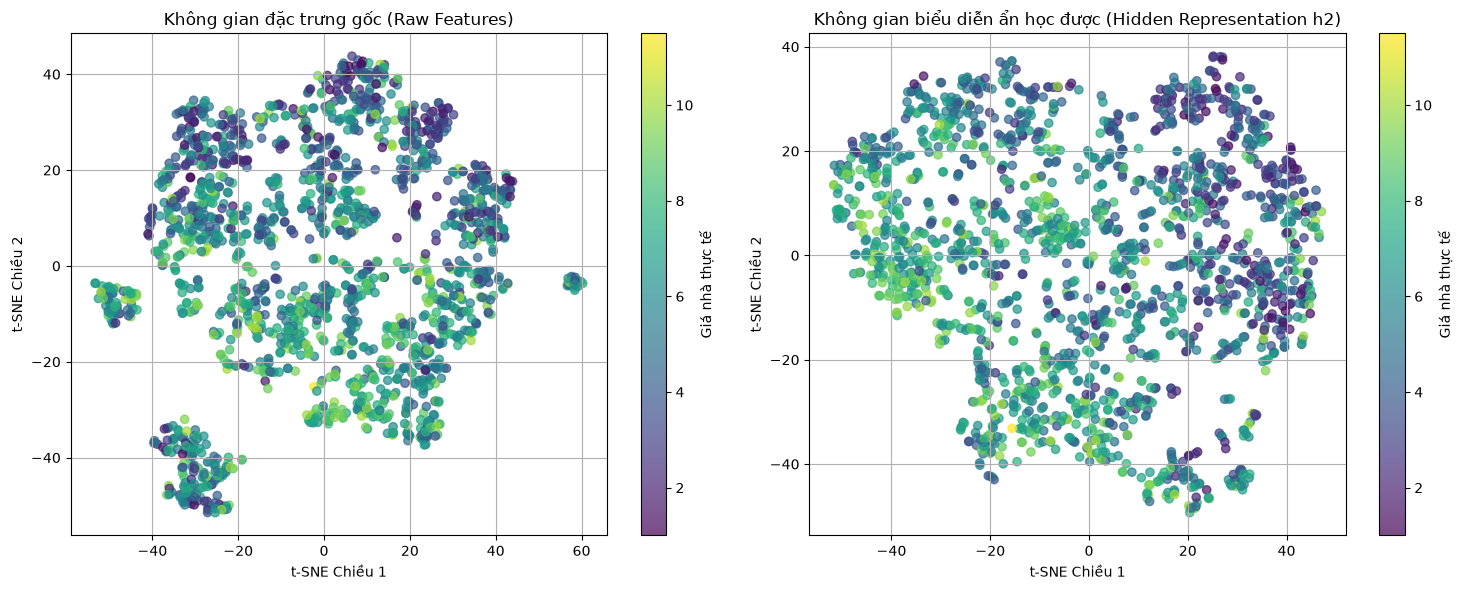

In [10]:
from sklearn.manifold import TSNE

# Lấy mẫu tối đa 2.000 điểm để t-SNE giảm chiều nhanh chóng
sample_size = min(2000, len(X_test))
sample_indices = np.random.choice(len(X_test), sample_size, replace=False)

X_sub = torch.tensor(X_test[sample_indices]).to(device)
y_sub = y_test[sample_indices].flatten()

with torch.no_grad():
    h_sub = model_exp2.get_representation(X_sub).cpu().numpy()

tsne = TSNE(n_components=2, random_state=42)
raw_2d = tsne.fit_transform(X_test[sample_indices])
h_2d = tsne.fit_transform(h_sub)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sc0 = axes[0].scatter(raw_2d[:, 0], raw_2d[:, 1], c=y_sub, cmap='viridis', alpha=0.7)
axes[0].set_title("Không gian đặc trưng gốc (Raw Features)")
axes[0].set_xlabel("t-SNE Chiều 1")
axes[0].set_ylabel("t-SNE Chiều 2")
plt.colorbar(sc0, ax=axes[0], label="Giá nhà thực tế")
axes[0].grid(True)

sc1 = axes[1].scatter(h_2d[:, 0], h_2d[:, 1], c=y_sub, cmap='viridis', alpha=0.7)
axes[1].set_title("Không gian biểu diễn ẩn học được (Hidden Representation h2)")
axes[1].set_xlabel("t-SNE Chiều 1")
axes[1].set_ylabel("t-SNE Chiều 2")
plt.colorbar(sc1, ax=axes[1], label="Giá nhà thực tế")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Đóng gói và lưu trữ mô hình

In [11]:
BEST_VN_HOUSING_MODEL = "vietnam_housing_mlp_best.pth"

# Lưu lại từ điển trọng số của mô hình Deeper MLP
torch.save(model_exp2.state_dict(), BEST_VN_HOUSING_MODEL)
print(f"Đã lưu trọng số mô hình tốt nhất thành công vào: {BEST_VN_HOUSING_MODEL}")

# Khởi tạo mô hình mới và nạp lại trọng số để xác nhận tính toàn vẹn
loaded_vn_model = DeeperHousingMLP()
loaded_vn_model.load_state_dict(torch.load(BEST_VN_HOUSING_MODEL))
loaded_vn_model.eval()
print("Mô hình đã được nạp lại thành công và sẵn sàng suy luận!")

Đã lưu trọng số mô hình tốt nhất thành công vào: vietnam_housing_mlp_best.pth
Mô hình đã được nạp lại thành công và sẵn sàng suy luận!
